In [1]:
#Statistics & Probability

#1. Descriptive Statistics

import numpy as np
import pandas as pd

data = [10, 20, 20, 30, 40, 50, 100]

# Basic descriptive statistics
print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Variance:", np.var(data))
print("Standard Deviation:", np.std(data))
print("Percentiles:", np.percentile(data, [25, 50, 75]))

# Pandas summary
df = pd.DataFrame(data, columns=["Values"])
print(df.describe())

Mean: 38.57142857142857
Median: 30.0
Variance: 783.6734693877551
Standard Deviation: 27.994168488950606
Percentiles: [20. 30. 45.]
           Values
count    7.000000
mean    38.571429
std     30.237158
min     10.000000
25%     20.000000
50%     30.000000
75%     45.000000
max    100.000000


In [2]:
#pip install scipy

In [3]:
import pandas as pd
import numpy as np
from scipy import stats

# Data
marks = [45, 55, 67, 49, 80, 75, 90, 45, 66, 77, 88, 59, 62, 70, 81]
s = pd.Series(marks)

# Central Tendency
print("Mean:", s.mean())
print("Median:", s.median())
print("Mode:", s.mode().values[0])

# Spread
print("Variance:", s.var())
print("Standard Deviation:", s.std())
print("Range:", s.max() - s.min())


Mean: 67.26666666666667
Median: 67.0
Mode: 45
Variance: 216.63809523809527
Standard Deviation: 14.718630888710242
Range: 45


In [4]:
# Data
temps = [29, 31, 28, 30, 33, 32, 31, 30, 29, 34]
s = pd.Series(temps)


# Spread & Shape
print("IQR:", stats.iqr(s))
print("Skewness:", s.skew())
print("Kurtosis:", s.kurt())

IQR: 2.5
Skewness: 0.41568489818642274
Kurtosis: -0.5686086121058604


In [5]:
#TASK 7

import pandas as pd

# Sales Data
data = {
    "Year": [2022, 2023, 2024],
    "Q1": [50, 70, 90],
    "Q2": [55, 75, 95],
    "Q3": [60, 78, 100],
    "Q4": [65, 85, 105]
}

df = pd.DataFrame(data)

# Year-wise descriptive statistics
print("Yearly Descriptive Statistics:\n")
print(df.set_index("Year").T.describe())

# Mean sales per year
print("\nMean sales per year:")
print(df.set_index("Year").mean(axis=1))

# Overall average
print("\nOverall Average Sales:", df.drop(columns="Year").values.flatten().mean()) #.values → Converts to NumPy array.#.flatten() → Turns 2D into 1D

Yearly Descriptive Statistics:

Year        2022       2023        2024
count   4.000000   4.000000    4.000000
mean   57.500000  77.000000   97.500000
std     6.454972   6.271629    6.454972
min    50.000000  70.000000   90.000000
25%    53.750000  73.750000   93.750000
50%    57.500000  76.500000   97.500000
75%    61.250000  79.750000  101.250000
max    65.000000  85.000000  105.000000

Mean sales per year:
Year
2022    57.5
2023    77.0
2024    97.5
dtype: float64

Overall Average Sales: 77.33333333333333


In [6]:
#TASK 8 

data = {
    "Student": ["A", "B", "C", "D", "E", "F"],
    "Gender": ["M", "F", "M", "F", "M", "F"],
    "Score": [78, 82, 65, 90, 72, 88]
}
df = pd.DataFrame(data)

# Group by Gender
grouped = df.groupby("Gender")["Score"].describe()
print(grouped)

        count       mean       std   min   25%   50%   75%   max
Gender                                                          
F         3.0  86.666667  4.163332  82.0  85.0  88.0  89.0  90.0
M         3.0  71.666667  6.506407  65.0  68.5  72.0  75.0  78.0


In [7]:
#2. Probability Basics

#Simple Probability :Example: A bag has 5 red balls and 3 blue balls. Find the probability of drawing a red ball.
# Total balls
red = 5
blue = 3
total = red + blue

# Probability of Red
p_red = red / total
print("Probability of drawing a red ball:", p_red)

Probability of drawing a red ball: 0.625


In [8]:
#Probability using Random Simulation :Example: Toss a fair coin 10,000 times and find probability of getting heads.
import numpy as np

trials = 10000
outcomes = np.random.choice(["H", "T"], size=trials)  # coin toss
p_heads = np.sum(outcomes == "H") / trials

print("Estimated Probability of Heads:", p_heads)

Estimated Probability of Heads: 0.4959


In [9]:
#Binomial:Example: Toss a coin 5 times. What is the probability of getting exactly 3 heads?

from scipy.stats import binom

n = 5   # trials
p = 0.5 # probability of success
k = 3   # number of successes

prob = binom.pmf(k, n, p) #exactly : pmf
print("P(3 heads in 5 tosses):", prob)

P(3 heads in 5 tosses): 0.3124999999999998


In [10]:
# A coin is tossed 8 times.
#1.Find the probability of getting exactly 3 heads.
#2.Find the probability of getting at least 5 heads.      P(X>OR EQUAL x)=P(X>=5) #F(x) = P(X<x) =1 -P(X>=x)
#3.Simulate 10,000 experiments and compare with theory.

import numpy as np
from scipy.stats import binom

n, p = 8, 0.5
print("Binomial P(3 heads):", binom.pmf(3, n, p))
print("Binomial P(≥5 heads):", 1 - binom.cdf(4, n, p))

# Simulation
simulation = np.random.binomial(n, p, 10000)
print("Simulated P(3 heads):", np.mean(simulation == 3))
print("Simulated P(≥5 heads) :",np.mean(simulation >= 5))

Binomial P(3 heads): 0.21874999999999992
Binomial P(≥5 heads): 0.36328125
Simulated P(3 heads): 0.2177
Simulated P(≥5 heads) : 0.3657


In [11]:
#Normal Distribution Probability:Example: Heights of students are normally distributed with mean = 170 cm, std = 10 cm.
                                        # Find probability that a randomly selected student is  taller than 180 cm #P(X>180)=1-cdf

from scipy.stats import norm

mean = 170
std = 10
p = 1 - norm.cdf(180, mean, std)
print("P(Height > 180):", p)

P(Height > 180): 0.15865525393145707


In [12]:
#Heights of students follow a normal distribution with mean = 170 cm and standard deviation = 8 cm.
#1.Find probability of a student being shorter than 180 cm.
#2.Find probability of a student being between 160 and 175 cm.

from scipy.stats import norm
mean, std = 170, 8
#  P(160<X<175)60<=P(X<175)-P(X<160)
print("Normal P(160 < height < 175):", norm.cdf(175, mean, std) - norm.cdf(160, mean, std))

Normal P(160 < height < 175): 0.6283646972844441


In [13]:
#The average number of calls received per minute at a call center is 3.
#1.What is the probability that exactly 4 calls come in a minute?
#2.What is the probability that at most 2 calls come in a minute?
#3.Simulate 1,000 minutes of calls.

import numpy as np
from scipy.stats import poisson

lam = 3
print("Poisson P(4 calls):", poisson.pmf(4, lam))
print("Poisson P(≤2 calls):", poisson.cdf(2, lam))

sim = np.random.poisson(lam, 1000)
print("Simulated mean calls:", np.mean(sim))

Poisson P(4 calls): 0.16803135574154085
Poisson P(≤2 calls): 0.42319008112684364
Simulated mean calls: 3.041


Uniform P(X < 15): 0.5
Uniform P(12 < X < 18): 0.6000000000000001


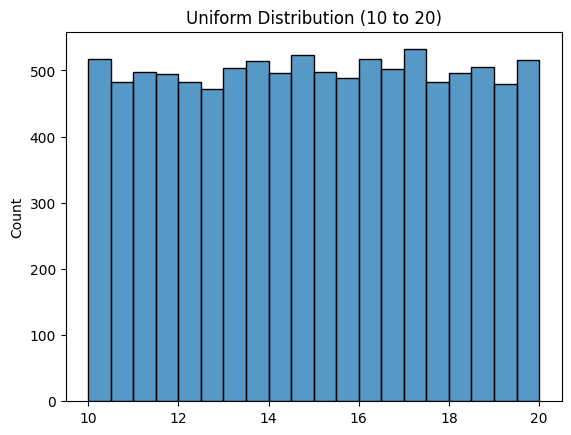

In [14]:
#A random variable X is uniformly distributed between 10 and 20.
#1.What is the probability that X is less than 15?
#2.What is the probability that X lies between 12 and 18? P(X<18) - P(X<12)
#3.Generate 10,000 random samples and plot histogram.

from scipy.stats import uniform
import seaborn as sns
import matplotlib.pyplot as plt

a, b = 10, 20
print("Uniform P(X < 15):", uniform.cdf(15, a, b-a)) # A, B-A ARE PARAMTERS
print("Uniform P(12 < X < 18):", uniform.cdf(18, a, b-a) - uniform.cdf(12, a, b-a))
# Simulation
sim = np.random.uniform(a, b, 10000) # NEED TO CONSIDER THE RANGE
sns.histplot(sim, bins=20)   #splits the range [10,20] into equal width bars
plt.title("Uniform Distribution (10 to 20)") 
plt.show()

In [15]:
#TASK 9

from scipy.stats import expon
import numpy as np

mean_wait = 10
rate = 1/mean_wait  
# (1) P(X < 5)
p_less5 = expon.cdf(5, scale=mean_wait)
# (2) P(X > 15) =1- cdf
p_more15 = expon.sf(15, scale=mean_wait)
# Simulation
rng = np.random.default_rng(0)
sim_data = rng.exponential(mean_wait, 10000) #np.random.dist = np.random.default_rng(0).exponential
sim_prob = np.mean(sim_data < 5)

print("Exponential Distribution")
print("P(Wait < 5):", p_less5)
print("P(Wait > 15):", p_more15)
print("Simulated P(Wait < 5):", sim_prob, "\n")

Exponential Distribution
P(Wait < 5): 0.3934693402873666
P(Wait > 15): 0.22313016014842982
Simulated P(Wait < 5): 0.4015 



In [16]:
#3. Inferential Statistics

#1.The population consists of numbers from 1 to 100.
#Take a random sample of size 15.
#Compare the sample mean with the population mean.

import numpy as np

# Population
population = np.arange(1, 101)
population_mean = np.mean(population)
print("Population Mean:", population_mean)

# Sample of size 15
sample = np.random.choice(population, size=15, replace=False)
sample_mean = np.mean(sample)

print("Sample:", sample)
print("Sample Mean:", sample_mean)
print("Difference from Population Mean:", abs(sample_mean - population_mean))

Population Mean: 50.5
Sample: [ 2 19 36 65 45 11 61 43 27 91  9 47  8 80 74]
Sample Mean: 41.2
Difference from Population Mean: 9.299999999999997


In [17]:
#Check how close the sample variance is to the population variance.
pop_variance = np.var(population)
print("Population Variance:", pop_variance)

sample = np.random.choice(population, size=15, replace=False)
sample_variance = np.var(sample, ddof=1)   # unbiased estimator
print("Sample Variance:", sample_variance)


Population Variance: 833.25
Sample Variance: 889.8571428571429


In [18]:
#Sampling with vs without replacement

sample_with_replacement = np.random.choice(population, size=5, replace=True)
sample_without_replacement = np.random.choice(population, size=5, replace=False)

print("With Replacement:", sample_with_replacement)
print("Without Replacement:", sample_without_replacement)

With Replacement: [62 89 90 27 77]
Without Replacement: [53 77 67 26  9]


In [19]:
#1.From numbers 1 to 100, take random samples of size 5, 20, and 50.
#2.Compare the sample means.
#3.Which one is closer to the population mean?


true_mean = np.mean(population)
print(true_mean)

for n in [5, 20, 50]:
    sample = np.random.choice(population, n, replace=False)
    print(f"Sample size {n}, mean = {np.mean(sample):.2f}")


50.5
Sample size 5, mean = 42.80
Sample size 20, mean = 58.70
Sample size 50, mean = 55.54


In [20]:
#TASK 10

# Simulated heights (in cm)
girls = np.random.normal(155, 5, 10)
boys = np.random.normal(165, 5, 10)
population = np.concatenate([girls, boys])

# Biased sample: only boys
sample_biased = np.random.choice(boys, 5, replace=False)

# Better sample: mix of boys and girls
sample_random = np.random.choice(population, 5, replace=False)

print("True population mean height:", np.mean(population))
print("Biased (only boys) sample mean:", np.mean(sample_biased))
print("Better random sample mean:", np.mean(sample_random))


True population mean height: 160.09543527436443
Biased (only boys) sample mean: 164.50760395360925
Better random sample mean: 155.42418203702545


In [21]:
#TASK 11

# Create population of marbles
marbles = np.array(["red"]*60 + ["blue"]*40)

# Pick 10 marbles randomly
sample = np.random.choice(marbles, 10, replace=False)

print("Sample:", sample)
print("Number of red marbles picked:", list(sample).count("red"))


Sample: ['red' 'red' 'red' 'blue' 'blue' 'red' 'blue' 'blue' 'blue' 'red']
Number of red marbles picked: 5


In [22]:
#Hypothesis Testing (Decision-Making)

#One-Sample t-Test (compare mean to a claim)
# : A factory claims the average length of bolts is 5 cm. A random sample gives
import numpy as np
import scipy.stats as st

bolts = [4.9, 5.1, 4.8, 5.0, 5.2, 5.1, 4.7, 4.9, 5.0, 5.1]

t_stat, p_value = st.ttest_1samp(bolts, 5) #5 :population mean
print("T-statistic:", t_stat, "P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Mean ≠ 5")
else:
    print("Fail to Reject H0 → Mean may be 5")

T-statistic: -0.40824829046385464 P-value: 0.6926333242322562
Fail to Reject H0 → Mean may be 5


In [23]:
#Two-Sample t-Test

method_A = [78, 85, 82, 90, 76, 84, 80]
method_B = [72, 75, 78, 70, 74, 77, 73]

t_stat, p_value = st.ttest_ind(method_A, method_B)
print("T-statistic:", t_stat, "P-value:", p_value)
#0.05, 0.01,0.02,0.1
if p_value < 0.05:   
    print("Reject H0 → Methods differ")
else:
    print("Fail to Reject H0 → Methods may be same")

T-statistic: 3.867437746335499 P-value: 0.0022382519062412874
Reject H0 → Methods differ


In [24]:
#Paired t test

before = [60, 65, 70, 68, 72, 66, 64]
after  = [68, 70, 75, 74, 78, 71, 70]

t_stat, p_value = st.ttest_rel(before, after)
print("T-statistic:", t_stat, "P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Improvement is significant")
else:
    print("Fail to Reject H0 → No significant improvement")

T-statistic: -14.495689014324224 P-value: 6.757136027857826e-06
Reject H0 → Improvement is significant


In [25]:
#Proportion z-Test 

p0 = 0.6  # claimed proportion
n = 200
success = 118
p_hat = success / n

se = np.sqrt(p0 * (1 - p0) / n)
z = (p_hat - p0) / se
p_value = 2 * (1 - st.norm.cdf(abs(z)))

print("Z-statistic:", z, "P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Satisfaction rate ≠ 60%")
else:
    print("Fail to Reject H0 → Satisfaction rate may be 60%")

Z-statistic: -0.28867513459481314 P-value: 0.7728299926844473
Fail to Reject H0 → Satisfaction rate may be 60%


In [26]:
#Chi sqaure

observed = np.array([8, 9, 10, 12, 11, 10])
expected = np.array([10, 10, 10, 10, 10, 10])

chi_stat, p_value = st.chisquare(observed, expected)
print("Chi-square:", chi_stat, "P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Die not fair")
else:
    print("Fail to Reject H0 → Die may be fair")

Chi-square: 1.0 P-value: 0.9625657732472964
Fail to Reject H0 → Die may be fair


In [27]:
#ANOVA
diet_A = [5, 6, 7, 8, 6, 7]
diet_B = [8, 9, 7, 10, 9, 8]
diet_C = [6, 5, 7, 6, 6, 5]

f_stat, p_value = st.f_oneway(diet_A, diet_B, diet_C)
print("F-statistic:", f_stat, "P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → At least one diet differs")
else:
    print("Fail to Reject H0 → All diets may be same")

F-statistic: 12.530120481927712 P-value: 0.0006314409794466205
Reject H0 → At least one diet differs


In [28]:
#pip install statsmodels

In [29]:
#One-sample proportion z-test : Is the proportion of left-handed students different from 10%?

from statsmodels.stats.proportion import proportions_ztest

count = 30   # left-handed students
nobs = 200   # total students
value = 0.10 # claimed proportion (10%)

stat, p_value = proportions_ztest(count, nobs, value)
print("Z-statistic:", round(stat, 3))
print("P-value:", round(p_value, 3))

Z-statistic: 1.98
P-value: 0.048


In [30]:
#Two-proportion z-test: Are men and women equally likely to pass an exam?

from statsmodels.stats.proportion import proportions_ztest

count = np.array([40, 30])   # passed [men, women]
nobs = np.array([100, 120])  # total [men, women]

stat, p_value = proportions_ztest(count, nobs)
print("Z-statistic:", round(stat, 3))
print("P-value:", round(p_value, 3))

Z-statistic: 2.378
P-value: 0.017


In [31]:
#Normality test (Shapiro-Wilk) : Often used before t-tests (assumption check).

data = [12, 13, 11, 15, 14, 13, 12, 11]
stat, p_value = st.shapiro(data)
print("Statistic:", round(stat, 3), "P-value:", round(p_value, 3))

Statistic: 0.934 P-value: 0.557


In [32]:
#TASK 12

import numpy as np

observed = np.array([[40, 35],
                     [30, 45]])

chi2, p_value, dof, expected = st.chi2_contingency(observed)
print("Chi-square:", chi2)
print("P-value:", p_value)


Chi-square: 2.169642857142857
P-value: 0.14075892055904546


In [33]:
#TASK 13

A = [78, 80, 75, 79, 77]
B = [72, 74, 70, 73, 71]
C = [85, 86, 84, 87, 83]

f_stat, p_value = st.f_oneway(A, B, C)
print("F-statistic:", f_stat)
print("P-value:", p_value)


F-statistic: 73.12643678160929
P-value: 1.9009813147052083e-07


In [ ]:
#pip install scikit-learn

In [46]:
#4.Predictive modelling :
#Linear & Logistric regression

import numpy as np
from sklearn.linear_model import LinearRegression

# Data (ad budget in $1000 vs sales)
budget = np.array([10, 20, 30, 40, 50, 60]).reshape(-1, 1) # scikit-learn expects the input X to be 2D
sales = np.array([25, 35, 50, 55, 65, 80])

# Build model
model = LinearRegression()
model.fit(budget, sales)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

# Prediction for 60k budget
pred = model.predict([[30]])
#print(pred)
print("Predicted Sales:", pred)

Intercept: 14.666666666666657
Slope: [1.05714286]
Predicted Sales: [46.38095238]


In [47]:
#multiple regression
import pandas as pd

data = pd.DataFrame({
    "Hours": [5, 6, 7, 8, 9, 10],
    "Assignments": [6, 7, 8, 8, 9, 10],
    "Score": [60, 65, 70, 75, 80, 90]
})

X = data[["Hours", "Assignments"]]
y = data["Score"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

pred = model.predict([[8, 10]])
print("Predicted Score:", pred)

Intercept: 25.416666666666657
Coefficients: [4.16666667 2.08333333]
Predicted Score: [79.58333333]


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [48]:
#Predict house price using size (sq ft). Also, calculate the R² score to check accuracy of your regression model.
from sklearn.metrics import r2_score

size = np.array([800, 1000, 1200, 1500, 1800, 2000]).reshape(-1, 1)
price = np.array([150000, 180000, 200000, 240000, 300000, 330000])

model = LinearRegression()
model.fit(size, price)

# Predictions
pred = model.predict(size)

print("Slope:", model.coef_)
print("Intercept:", model.intercept_)
print("R² Score:", r2_score(price, pred)) #goodness of fit

Slope: [150.07656968]
Intercept: 25727.41194486982
R² Score: 0.9910716865555202


In [37]:
#TASK 14
import numpy as np

size = np.array([800, 1000, 1200, 1500, 1800]).reshape(-1, 1)
price = np.array([150000, 180000, 200000, 240000, 300000])

model = LinearRegression().fit(size, price)

pred = model.predict(size)
residuals = price - pred

print("Actual Prices:", price)
print("Predicted Prices:", pred)
print("Residuals (Errors):", residuals)

Actual Prices: [150000 180000 200000 240000 300000]
Predicted Prices: [147183.5443038  176234.17721519 205284.81012658 248860.75949367
 292436.70886076]
Residuals (Errors): [ 2816.4556962   3765.82278481 -5284.81012658 -8860.75949367
  7563.29113924]


In [38]:
#TASK 15

import pandas as pd
data = pd.DataFrame({
    "EngineSize": [1500, 1600, 1800, 2000],
    "HorsePower": [100, 120, 140, 160],
    "CarAge": [5, 4, 3, 2],
    "Price": [8000, 9000, 12000, 15000]
})

X = data[["EngineSize", "HorsePower", "CarAge"]]
y = data["Price"]

model = LinearRegression().fit(X, y) #to find best fit

print("Coefficients:", model.coef_)
print("Features:", X.columns)

# Find feature with max impact
important_feature = X.columns[np.argmax(abs(model.coef_))]      #index of the largest absolute coefficient.#gets the corresponding feature name.
print("Most important feature:", important_feature)


Coefficients: [ 20.         -49.87531172   2.49376559]
Features: Index(['EngineSize', 'HorsePower', 'CarAge'], dtype='object')
Most important feature: HorsePower


In [39]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = np.array([70, 75, 80, 85, 90])
y_pred = np.array([68, 77, 79, 88, 85])

# Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mae)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.6
RMSE: 1.61245154965971


Confusion Matrix:
 [[3 1]
 [1 3]]
Accuracy: 0.75
Precision: 0.75
Recall: 0.75
F1 Score: 0.75


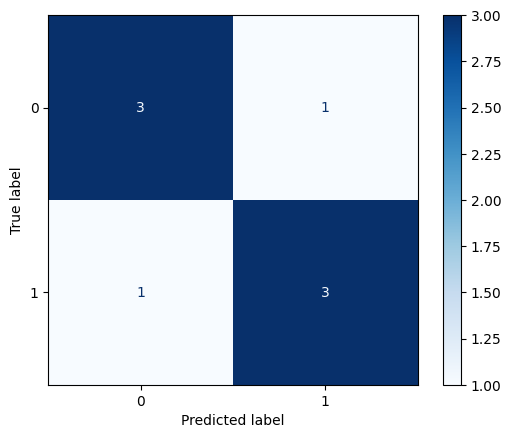

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Actual and Predicted labels (balanced data)
y_true = [1, 0, 1, 0, 1, 0, 1, 0]
y_pred = [1, 0, 0, 0, 1, 1, 1, 0]

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.show()

In [41]:
y_true = [1,0,1,1,0,0,1,0]
y_pred = [1,0,0,1,0,1,1,0]

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Manual calculations
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
 [[3 1]
 [1 3]]
Accuracy: 0.75
Precision: 0.75
Recall: 0.75
F1 Score: 0.75


Confusion Matrix:
 [[4 0]
 [0 4]]
Precision: 1.0
Recall: 1.0
Confusion Matrix:
 [[4 0]
 [1 3]]
Precision: 1.0
Recall: 0.75


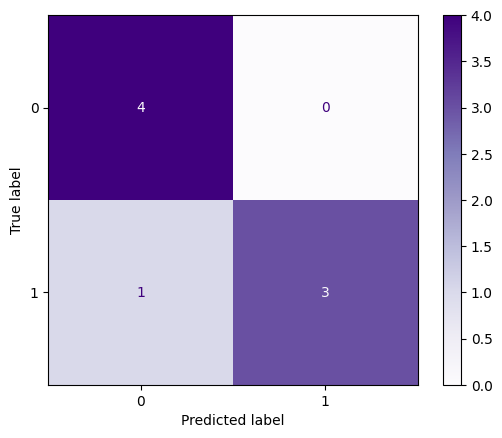

In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score

y_true = [1, 0, 1, 0, 1, 0, 1, 0]
y_prob = [0.9, 0.3, 0.8, 0.4, 0.7, 0.2, 0.6, 0.1]

for threshold in [0.5, 0.7]:
    y_pred = [1 if p >= threshold else 0 for p in y_prob]   #[1 if p >= 0.5 else 0 for p in y_prob]
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Purples")
plt.show()

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Create a small dataset
data = pd.DataFrame({
    "StudyHours": [1, 2, 3, 4, 5, 6, 7, 8],
    "Score": [20, 35, 50, 60, 65, 70, 80, 90]
})

# Features (X) and Target (y)
X = data[["StudyHours"]]
y = data["Score"]

# Split into Train (75%) and Test (25%): 6 rows for train and 2 row testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training Features:\n", X_train)
print("\nTraining Labels:\n", y_train)

print("\nTesting Features:\n", X_test)
print("\nTesting Labels:\n", y_test)

from sklearn.linear_model import LinearRegression

# Train model
model = LinearRegression().fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)
print("Predicted scores:", preds)
print("Actual scores:", list(y_test))


Training Features:
    StudyHours
0           1
7           8
2           3
4           5
3           4
6           7

Training Labels:
 0    20
7    90
2    50
4    65
3    60
6    80
Name: Score, dtype: int64

Testing Features:
    StudyHours
1           2
5           6

Testing Labels:
 1    35
5    70
Name: Score, dtype: int64
Predicted scores: [35.9 73.3]
Actual scores: [35, 70]


In [44]:
data2 = pd.DataFrame({
    "StudyHours": [2, 3, 4, 5, 6, 7, 8],
    "SleepHours": [8, 7, 7, 6, 6, 5, 5],
    "Score": [40, 45, 50, 60, 70, 80, 90]
})

X2 = data2[["StudyHours", "SleepHours"]]
y2 = data2["Score"]

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.3, random_state=42)
model2 = LinearRegression().fit(X_train, y_train)

print("Predictions:", model2.predict(X_test))
print("Actual:", list(y_test))

Predictions: [30. 40. 80.]
Actual: [40, 45, 80]


In [45]:
#TASK 16 :
data3 = pd.DataFrame({
    "TVSpend": [40,50,60,70,80,90,100,110],
    "SocialMediaSpend": [10,15,20,25,30,35,40,45],
    "Sales": [150,170,190,210,230,250,270,290]
})

X3 = data3[["TVSpend","SocialMediaSpend"]]
y3 = data3["Sales"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.25, random_state=42)
model3 = LinearRegression().fit(X_train3, y_train3)
y_pred3 = model3.predict(X_test3)

print("Predictions:", y_pred3)
print("Actual:", list(y_test3))

new_campaign = pd.DataFrame({"TVSpend":[120],"SocialMediaSpend":[50]})
print("Predicted Sales:", model3.predict(new_campaign))


Predictions: [170. 250.]
Actual: [170, 250]
Predicted Sales: [310.]
